In [ ]:
!pip uninstall scikit-learn -y
!pip install --upgrade pip
!pip install scikit-learn

In [ ]:
!pip uninstall imbalanced-learn -y
!pip install imbalanced-learn

### Code 1: SMOTE Before Train-Test Split

[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Index(['Unnamed: 0', 'description', 'medical_specialty', 'sample_name',
       'transcription', 'keywords'],
      dtype='object')
Index(['description', 'medical_specialty', 'sample_name', 'transcription',
       'keywords', 'cleaned_transcription'],
      dtype='object')
[0 2 2 ... 0 0 0]
<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 971983 stored elements and shape (4999, 6000)>
  Coords	Values
  (0, 5173)	0.07635630514817295
  (0, 5975)	0.03193625429416041
  (0, 3511)	0.03128282937943825
  (0, 5893)	0.05608931641713752
  (0, 1887)	0.04872326196776577
  (0, 4109)	0.06568046458261259
  (0, 994)	0.06025318492650167
  (0, 150)	0.20353308851951551
  (0, 5674)	0.18144404083725288
  (0, 5388)	0.10351278263496011
  (0, 5945)	0.07914459031103166
  (0, 3713)	0.04472448047548372
  (0, 5545)	0.09000697826607999
  (0, 893)	0.11126830298380402
  (0, 5999)	0.21765905911943248
  (0, 5940)	0.09183501391224375
  (0, 4843)	0.07244628541284122
  (0, 5434)	0.036990852756090736
  (0, 4766

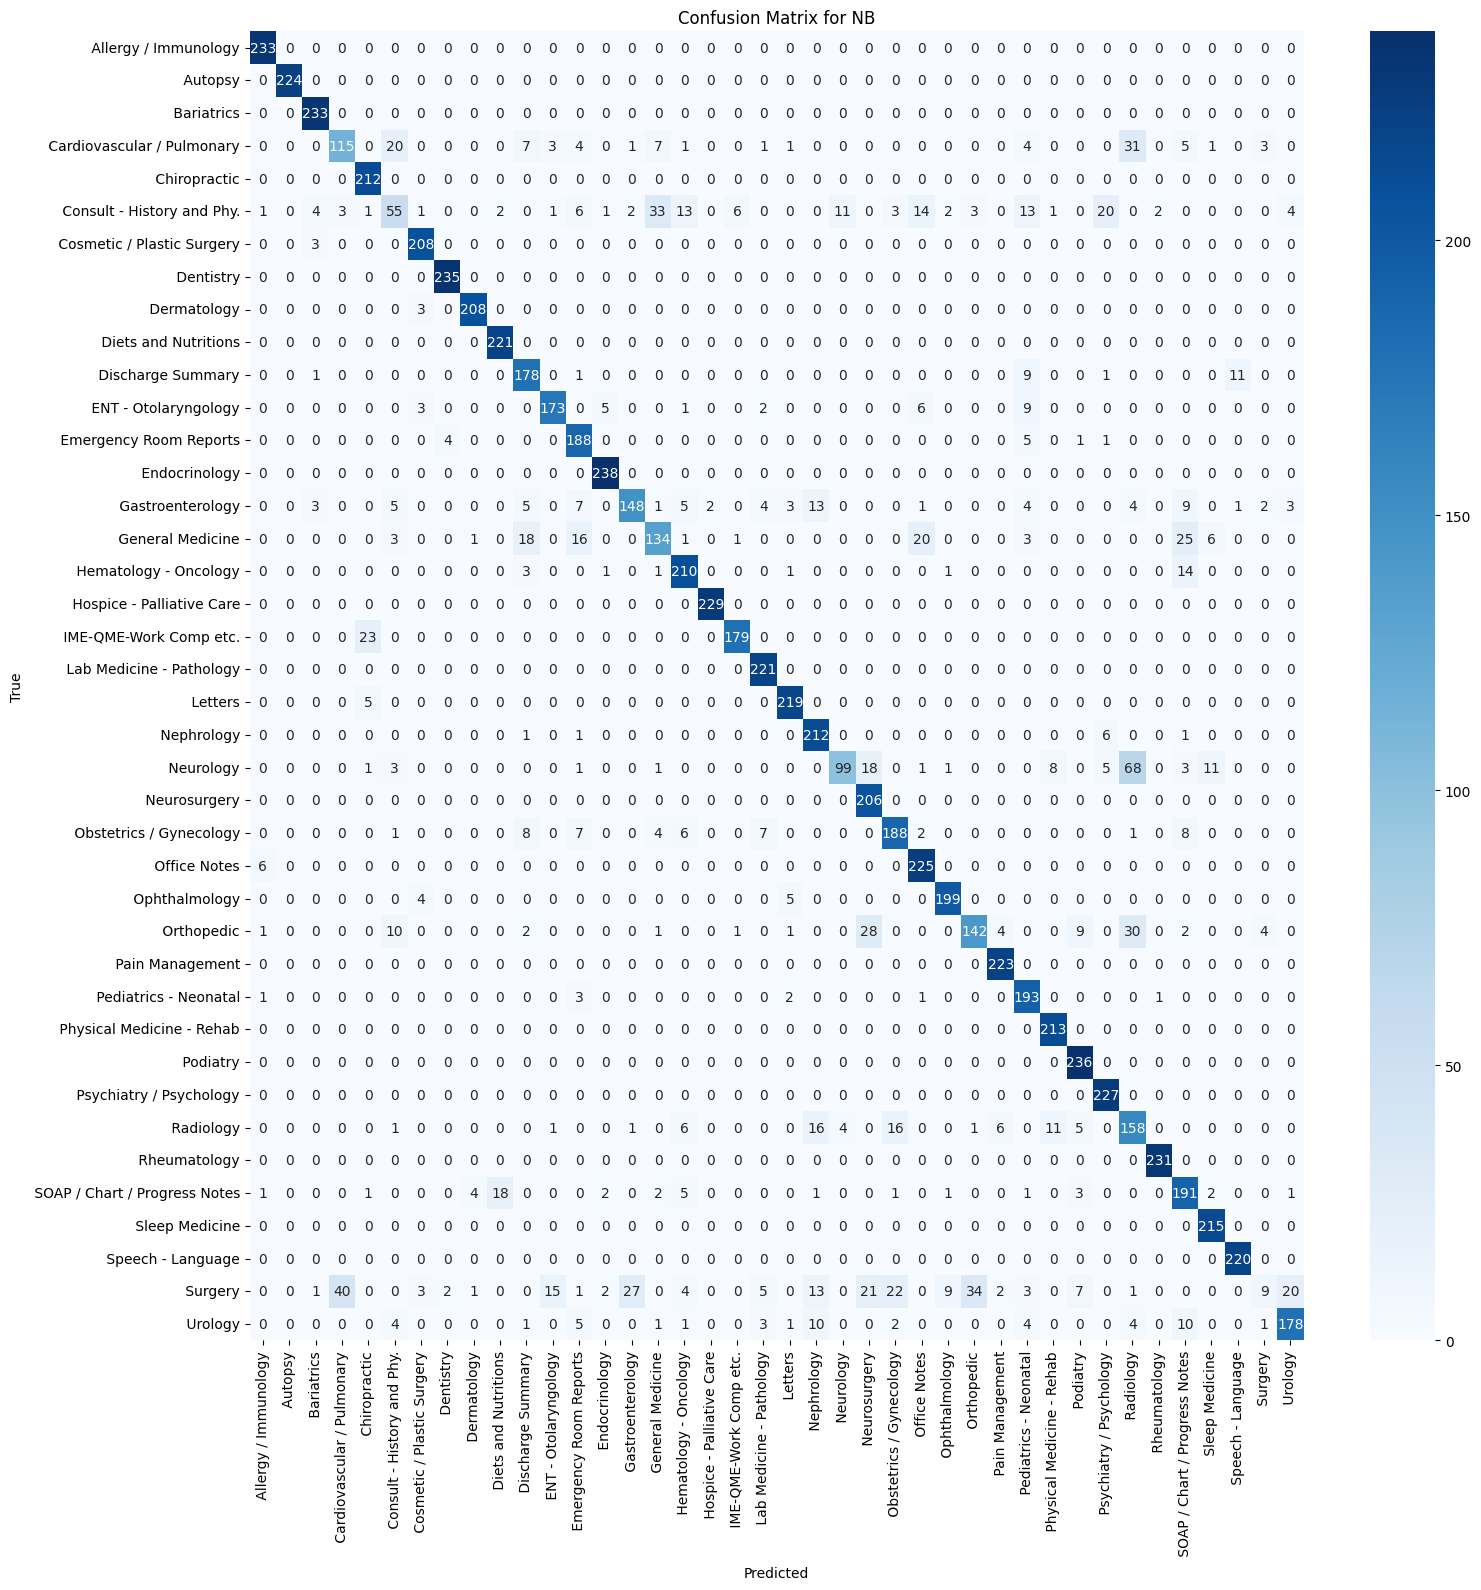

In [2]:
! pip install nltk
import nltk
from nltk.corpus import stopwords

import pandas as pd 

# Download the stopwords dataset if not already downloaded
nltk.download('stopwords')

# Objective, Can you correctly classify the medical specialties based on the transcription text
#Let us import all the necessary libraries
import os
import numpy as np  
import pandas as pd 
import time
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

import nltk
import re, string
from sklearn.model_selection import RandomizedSearchCV
from nltk import word_tokenize, sent_tokenize

from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import RandomizedSearchCV, cross_validate
from sklearn.metrics import classification_report
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.multiclass import OneVsRestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelBinarizer,LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from mlxtend.plotting import plot_confusion_matrix
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_validate

# Objective, Can you correctly classify the medical specialties based on the transcription text
#Let us import all the necessary libraries
import os
import numpy as np  
import pandas as pd 
import time
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

import nltk
import re, string
from sklearn.model_selection import RandomizedSearchCV
from nltk import word_tokenize, sent_tokenize

from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.multiclass import OneVsRestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelBinarizer,LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from mlxtend.plotting import plot_confusion_matrix
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_validate


import warnings
warnings.filterwarnings("ignore")


import warnings
warnings.filterwarnings("ignore")

# Use the stopwords
stop_words = set(stopwords.words('english'))

#EDA
data = pd.read_csv('/kaggle/input/medicaltranscriptions/mtsamples.csv')
print(data.columns)
#data.head(5)

data.drop('Unnamed: 0',axis=1,inplace=True)

data.columns

# a function to preprocess the data
def Preprocessing(text):
    text = str(text)
    text = text.lower()
    text = re.sub(r'\([^)]*\)', '', text)
    text = re.sub('"','', text) 
    text = re.sub(r"'s\b","",text)
    text = re.sub("[^a-zA-Z]", " ", text) 
    tokens = [w for w in text.split() if not w in stop_words]
    long_words = [i for i in tokens if len(i)>=3]
    return (" ".join(long_words)).strip()

data['cleaned_transcription'] = data['transcription'].apply(Preprocessing)

print(data.columns)

# creating feature vectors and target vector
transcripts = data.cleaned_transcription.values
Y = data.medical_specialty.values

# label encode our categorical target variable
le = LabelEncoder()
Y = le.fit_transform(Y)

print(Y)

# function to create document-term matrix
def create_vec(strings):
  #tf = TfidfVectorizer(analyzer="char_wb", ngram_range=(1,3))
  tf = TfidfVectorizer(max_features = 6000, ngram_range=(1,3), min_df=5, max_df=0.9)
  tf.fit(strings)
  X = tf.fit_transform(strings)
  return X
vecs = create_vec(transcripts)# a function to preprocess the data

print(vecs)

# applying SMOTE oversampling method to upsample minority class labels
sm = SMOTE()
x_res, y_res = sm.fit_resample(vecs,Y)

df = pd.DataFrame({"class":list(y_res)})
df.head()

df['class'].value_counts()

# Splitting data into train:test by 80:20
x_train, x_val, y_train, y_val = train_test_split(x_res, y_res, test_size=0.2, random_state = 42)

x_train = x_train.toarray()
print('\nTraining features shape: ',x_train.shape)

x_val =x_val.toarray()
print('Test features shape:     ',x_val.shape)

# a function to train and evaluate model
def train_model(model, x_train,x_test,y_train,y_test):
  model.fit(x_train,y_train)
  prediction = model.predict(x_test)
  print('Accuracy',round(accuracy_score(prediction, y_test)*100, 0),'%')
  return model

# Naive Bayes Classification model
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import RandomizedSearchCV, cross_validate
from sklearn.metrics import classification_report
import numpy as np

# Define the parameter distribution for RandomizedSearchCV
param_dist = {
    'var_smoothing': np.logspace(0, -9, 100)  # range of possible smoothing values, from 1 to 1e-9
}

# Initialize the GaussianNB classifier
classifier = GaussianNB()

# Apply RandomizedSearchCV with 2-fold cross-validation
random_search = RandomizedSearchCV(classifier, param_distributions=param_dist, n_iter=50, cv=5, verbose=1, random_state=42, n_jobs=-1)

# Train the Naive Bayes model with RandomizedSearchCV
random_search.fit(x_train, y_train)

# Get the best parameters found by RandomizedSearchCV
print(f"Best parameters found: {random_search.best_params_}")

# Cross-validation with 2 folds using the best found model
cv_results = cross_validate(random_search.best_estimator_, x_train, y_train, cv=2)

# Print cross-validation results (accuracy, fit time, score time)
print("Cross-validation results: ", cv_results)

# Predictions using the best model from RandomizedSearchCV
prediction = random_search.best_estimator_.predict(x_val)

# Print classification report
print('Classification report for Naive Bayes with RandomizedSearchCV: \n', classification_report(y_val, prediction, target_names=list(le.classes_), digits=4)) 

# Confusion Matrix Naive Bayes
conf_matrix = confusion_matrix(y_val, prediction)

# Plotting the confusion matrix
plt.figure(figsize=(17, 17))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix for NB')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

### Code 2: SMOTE After Train-Test Split

[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Index(['Unnamed: 0', 'description', 'medical_specialty', 'sample_name',
       'transcription', 'keywords'],
      dtype='object')
Index(['description', 'medical_specialty', 'sample_name', 'transcription',
       'keywords', 'cleaned_transcription'],
      dtype='object')
[0 2 2 ... 0 0 0]
<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 971983 stored elements and shape (4999, 6000)>
  Coords	Values
  (0, 5173)	0.07635630514817295
  (0, 5975)	0.03193625429416041
  (0, 3511)	0.03128282937943825
  (0, 5893)	0.05608931641713752
  (0, 1887)	0.04872326196776577
  (0, 4109)	0.06568046458261259
  (0, 994)	0.06025318492650167
  (0, 150)	0.20353308851951551
  (0, 5674)	0.18144404083725288
  (0, 5388)	0.10351278263496011
  (0, 5945)	0.07914459031103166
  (0, 3713)	0.04472448047548372
  (0, 5545)	0.09000697826607999
  (0, 893)	0.11126830298380402
  (0, 5999)	0.21765905911943248
  (0, 5940)	0.09183501391224375
  (0, 4843)	0.07244628541284122
  (0, 5434)	0.036990852756090736
  (0, 4766

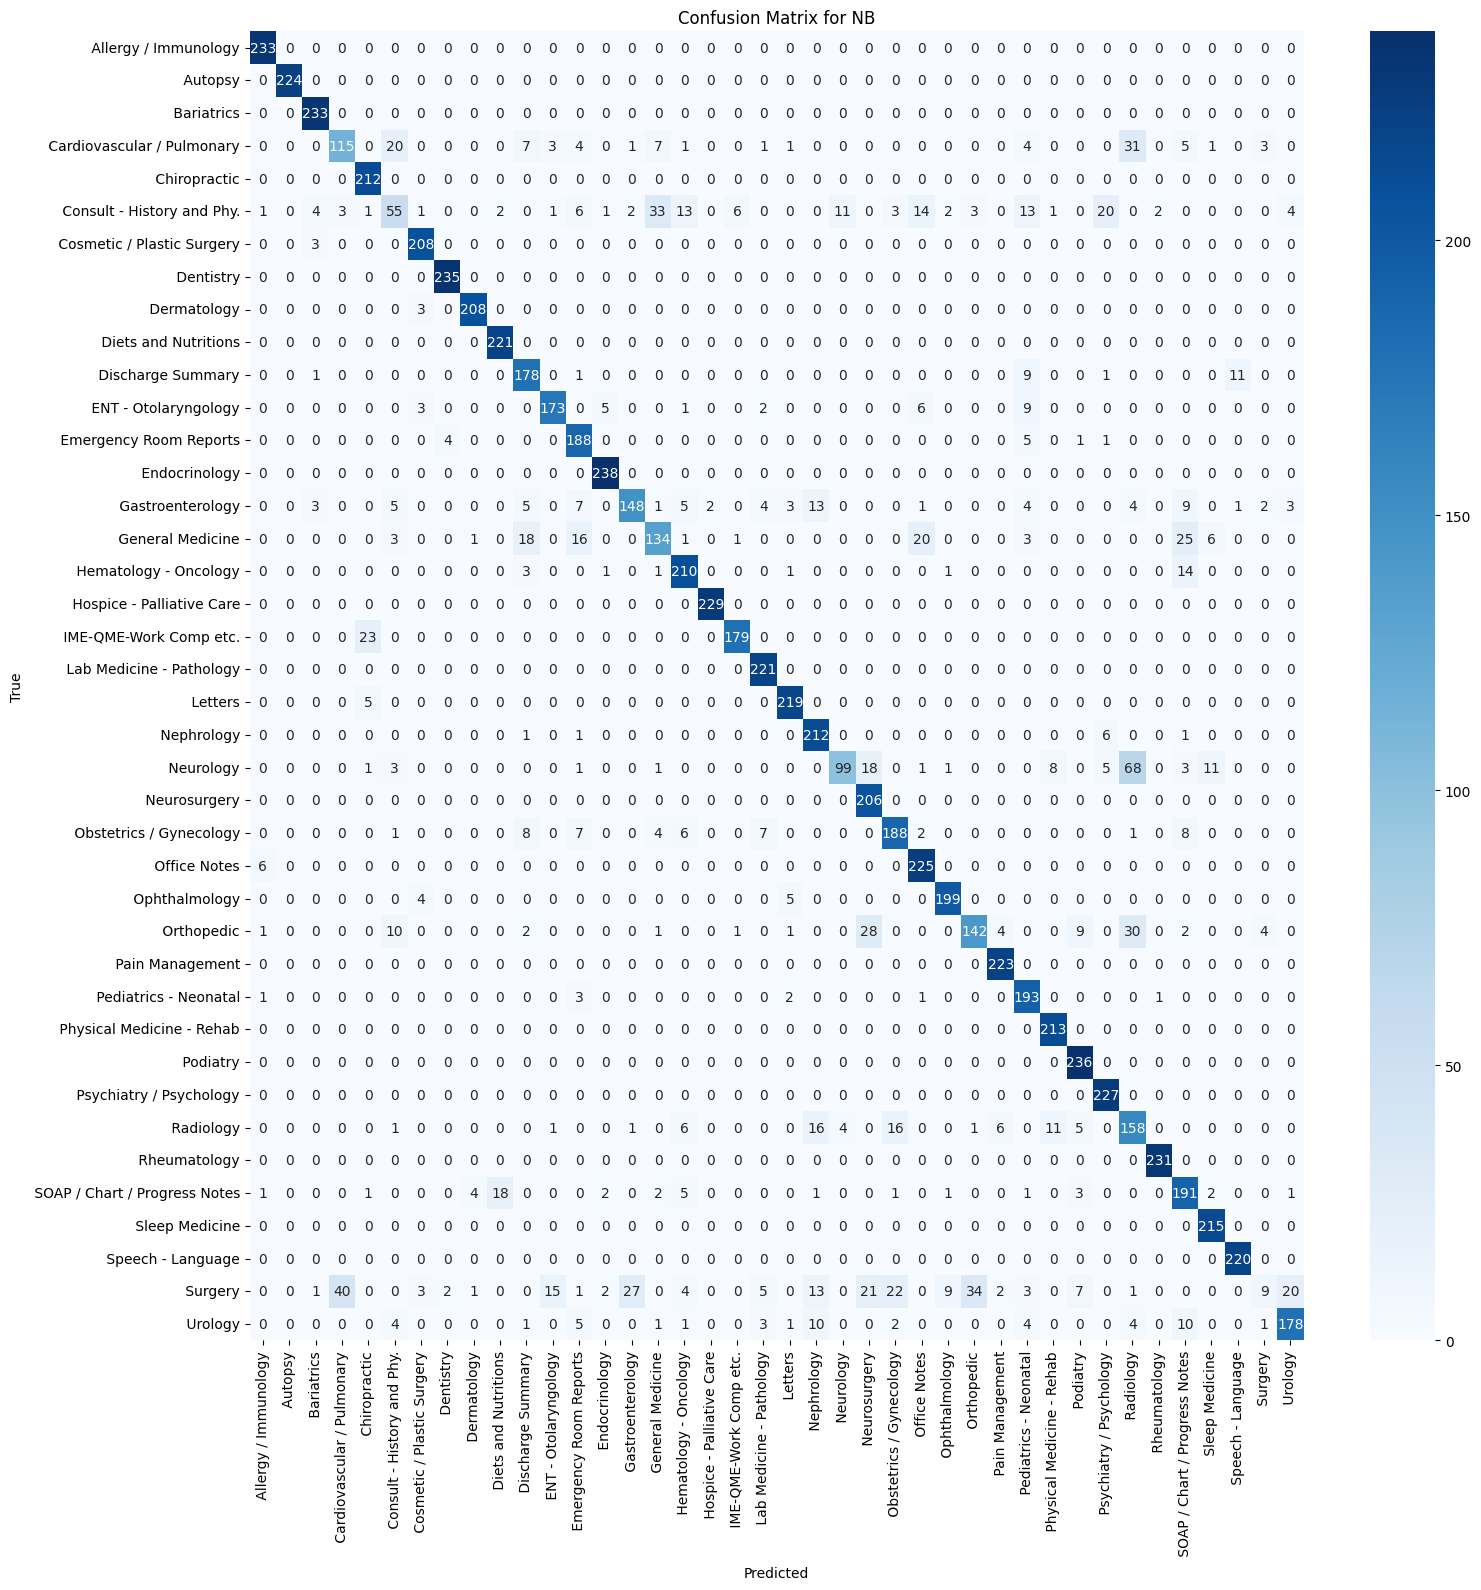

In [3]:
! pip install nltk
import nltk
from nltk.corpus import stopwords

# Download the stopwords dataset if not already downloaded
nltk.download('stopwords')

# Use the stopwords
stop_words = set(stopwords.words('english'))

#EDA
data = pd.read_csv('/kaggle/input/medicaltranscriptions/mtsamples.csv')
print(data.columns)
#data.head(5)

data.drop('Unnamed: 0',axis=1,inplace=True)

data.columns 

# a function to preprocess the data
def Preprocessing(text):
    text = str(text)
    text = text.lower()
    text = re.sub(r'\([^)]*\)', '', text)
    text = re.sub('"','', text) 
    text = re.sub(r"'s\b","",text)
    text = re.sub("[^a-zA-Z]", " ", text) 
    tokens = [w for w in text.split() if not w in stop_words]
    long_words = [i for i in tokens if len(i)>=3]
    return (" ".join(long_words)).strip()

data['cleaned_transcription'] = data['transcription'].apply(Preprocessing)

print(data.columns)

# creating feature vectors and target vector
transcripts = data.cleaned_transcription.values
Y = data.medical_specialty.values

# label encode our categorical target variable
le = LabelEncoder()
Y = le.fit_transform(Y)

print(Y)

# function to create document-term matrix
def create_vec(strings):
  #tf = TfidfVectorizer(analyzer="char_wb", ngram_range=(1,3))
  tf = TfidfVectorizer(max_features = 6000, ngram_range=(1,3), min_df=5, max_df=0.9)
  tf.fit(strings)
  X = tf.fit_transform(strings)
  return X
vecs = create_vec(transcripts)# a function to preprocess the data

print(vecs)

# Splitting data into train:test by 80:20
x_train, x_val, y_train, y_val = train_test_split(x_res, y_res, test_size=0.2, random_state = 42)

x_train = x_train.toarray()
print('\nTraining features shape: ',x_train.shape)

x_val =x_val.toarray()
print('Test features shape:     ',x_val.shape)

# applying SMOTE oversampling method to upsample minority class labels
sm = SMOTE()
x_res, y_res = sm.fit_resample(vecs,Y)

df = pd.DataFrame({"class":list(y_res)})
df.head()

df['class'].value_counts()

# a function to train and evaluate model
def train_model(model, x_train,x_test,y_train,y_test):
  model.fit(x_train,y_train)
  prediction = model.predict(x_test)
  print('Accuracy',round(accuracy_score(prediction, y_test)*100, 0),'%')
  return model

# Naive Bayes Classification model
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import RandomizedSearchCV, cross_validate
from sklearn.metrics import classification_report
import numpy as np

# Define the parameter distribution for RandomizedSearchCV
param_dist = {
    'var_smoothing': np.logspace(0, -9, 100)  # range of possible smoothing values, from 1 to 1e-9
}

# Initialize the GaussianNB classifier
classifier = GaussianNB()

# Apply RandomizedSearchCV with 2-fold cross-validation
random_search = RandomizedSearchCV(classifier, param_distributions=param_dist, n_iter=50, cv=5, verbose=1, random_state=42, n_jobs=-1)

# Train the Naive Bayes model with RandomizedSearchCV
random_search.fit(x_train, y_train)

# Get the best parameters found by RandomizedSearchCV
print(f"Best parameters found: {random_search.best_params_}")

# Cross-validation with 2 folds using the best found model
cv_results = cross_validate(random_search.best_estimator_, x_train, y_train, cv=2)

# Print cross-validation results (accuracy, fit time, score time)
print("Cross-validation results: ", cv_results)

# Predictions using the best model from RandomizedSearchCV
prediction = random_search.best_estimator_.predict(x_val)

# Print classification report
print('Classification report for Naive Bayes with RandomizedSearchCV: \n', classification_report(y_val, prediction, target_names=list(le.classes_), digits=4)) 

# Confusion Matrix Naive Bayes
conf_matrix = confusion_matrix(y_val, prediction)

# Plotting the confusion matrix
plt.figure(figsize=(17, 17))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix for NB')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()